In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv')
test_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv')

In [3]:
print(test_df.shape)
print(train_df.shape)

(220, 26)
(880, 26)


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [5]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [6]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

knn_preds = knn.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_preds)

print("KNN Accuracy:", knn_accuracy)
print(classification_report(y_test, knn_preds))

KNN Accuracy: 0.8590909090909091
              precision    recall  f1-score   support

           0       0.87      0.82      0.85        74
           1       0.83      0.93      0.88        72
           2       0.88      0.82      0.85        74

    accuracy                           0.86       220
   macro avg       0.86      0.86      0.86       220
weighted avg       0.86      0.86      0.86       220



In [7]:
#Hyperparameter tuning KNN

In [8]:
from sklearn.model_selection import GridSearchCV

In [9]:
knn_param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15,17,19,21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'hamming']
}

In [10]:
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(x_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)
print("Best KNN CV accuracy:", grid_knn.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


Best KNN parameters: {'metric': 'hamming', 'n_neighbors': 21, 'weights': 'uniform'}
Best KNN CV accuracy: 0.8818181818181821


In [11]:
best_knn = grid_knn.best_estimator_
tuned_knn_preds = best_knn.predict(x_test)
tuned_knn_accuracy = accuracy_score(y_test, tuned_knn_preds)

print("Tuned KNN Test Accuracy for Test Data:", tuned_knn_accuracy)
print(classification_report(y_test, tuned_knn_preds))

tuned_knn_preds_t = best_knn.predict(x_train)
tuned_knn_accuracy_t = accuracy_score(y_train, tuned_knn_preds_t)

print("Tuned KNN Test Accuracy for Training Data:", tuned_knn_accuracy_t)
print(classification_report(y_train, tuned_knn_preds_t))

Tuned KNN Test Accuracy for Test Data: 0.8818181818181818
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        74
           1       0.97      0.89      0.93        72
           2       0.80      0.93      0.86        74

    accuracy                           0.88       220
   macro avg       0.89      0.88      0.88       220
weighted avg       0.89      0.88      0.88       220

Tuned KNN Test Accuracy for Training Data: 0.8829545454545454
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       299
           1       0.92      0.88      0.90       286
           2       0.81      0.92      0.86       295

    accuracy                           0.88       880
   macro avg       0.89      0.88      0.88       880
weighted avg       0.89      0.88      0.88       880



In [12]:
import joblib

joblib.dump(best_knn, "../results/model_trained_files/knn_model.pkl")

['../results/model_trained_files/knn_model.pkl']

In [13]:
#Visualizing

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay

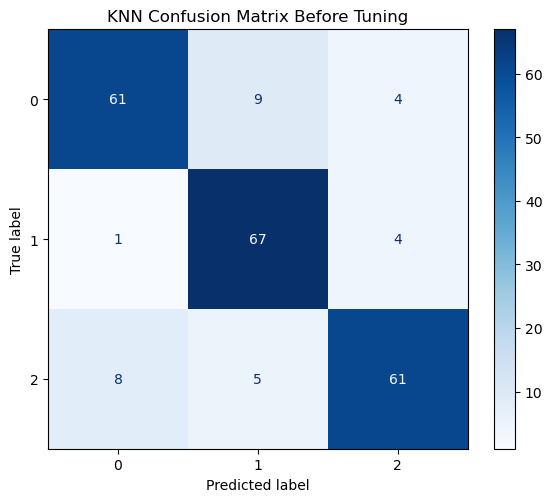

In [15]:
#Before tuning

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_preds,
    cmap="Blues",
    ax=ax
)
ax.set_title("KNN Confusion Matrix Before Tuning")
plt.tight_layout()
plt.show()

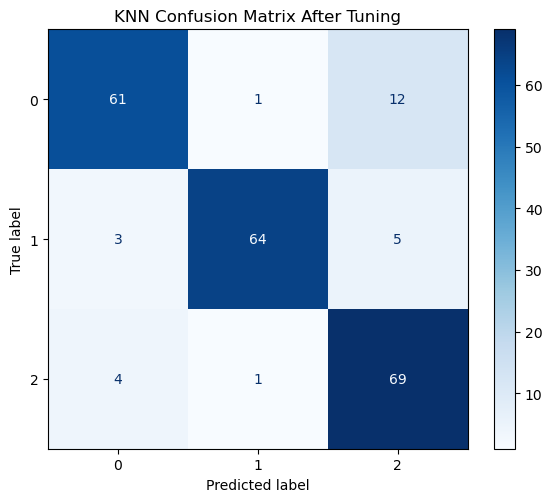

In [16]:
#After tuning

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_knn_preds,
    cmap="Blues",
    ax=ax
)
ax.set_title("KNN Confusion Matrix After Tuning")
plt.tight_layout()
plt.show()